<center>
<h1> TP-Projet d'optimisation numérique </h1>
<h1> Algorithme du lagrangien augmenté </h1>
</center>

## Implémentation

1. Implémenter l'algorithme du lagrangien augmenté, en utilisant les différentes méthodes
qui ont été vues en première partie pour la résolution de la suite de problèmes sans
contraintes (fichier `src/lagrangien_augmente.jl`). La spécification est donnée dans le fichier.
2. Vérifier que les tests ci-dessous passent.
 

In [8]:
include("../src/lagrangien_augmente.jl")
include("../test/tester_lagrangien_augmente.jl")

#
afficher = true # si true, alors affiche les résultats des algorithmes

#
tester_lagrangien_augmente(lagrangien_augmente, afficher);

Affichage des résultats des algorithmes : true

La valeur de μ_k est 20
La valeur de λ_k est 2
La valeur de μ_k est 40
La valeur de λ_k est 2
La valeur de μ_k est 40
La valeur de λ_k est 4.247191011235952
La valeur de μ_k est 80
La valeur de λ_k est 4.247191011235952
La valeur de μ_k est 80
La valeur de λ_k est 4.486536799414925
La valeur de μ_k est 80
La valeur de λ_k est 4.499283024820915
La valeur de μ_k est 80
La valeur de λ_k est 4.499961817889869
-------------------------------------------------------------------------
Résultats de : LA et newton appliqué à f1:
  * x0       = [0, 1, 1]
  * x_sol    = [0.5000042424566808, 1.2499978787716595, 0.5000042424566811]
  * f(x_sol) = 2.249961818051857
  * nb_iters = 7
  * flag     = 0
  * solution = [0.5, 1.25, 0.5]
La valeur de μ_k est 20
La valeur de λ_k est 2
La valeur de μ_k est 40
La valeur de λ_k est 2
La valeur de μ_k est 40
La valeur de λ_k est 4.247191011235952
La valeur de μ_k est 80
La valeur de λ_k est 4.247191011235952
La val

## Interprétation

 1. Commenter les résultats obtenus, en étudiant notamment les valeurs en sortie de $\lambda_k$ et $\mu_k$.
 2. Étudier l'influence du paramètre $\tau$ dans la performance de l'algorithme. Pour cela Vous réaliserez des tests numériques.

## Réponse à la Question 1



Après avoir affiché les différentes valeurs de $\lambda_k$ et $\mu_k$, on peut remarque que la valeur de $\mu_k$ augmente au fur et à mesures des itérations. Cependant, $\lambda_k$ semble légèrement augmenter avant de stagner vers la fin des itérations.

## Réponse à la Question 2


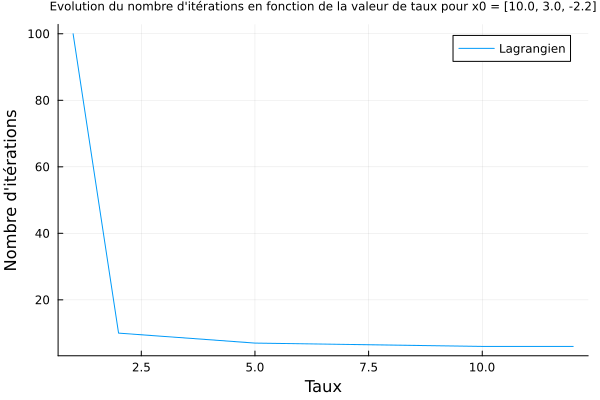

In [6]:
using Plots
include("../src/lagrangien_augmente.jl")

f(x) = 2 * (x[1] + x[2] + x[3] - 3)^2 + (x[1] - x[2])^2 + (x[2] - x[3])^2

gradf(x) = [4 * (x[1] + x[2] + x[3] - 3) + 2 * (x[1] - x[2]),
            4 * (x[1] + x[2] + x[3] - 3) - 2 * (x[1] - x[2]) + 2 * (x[2] - x[3]),
            4 * (x[1] + x[2] + x[3] - 3) - 2 * (x[2] - x[3])]

hessf(x) = [6 2 4; 2 8 2; 4 2 6]

c(x) =  x[1]+x[3]-1
gradc(x) = [1 ;0; 1]
hessc(x) = [0 0 0;0 0 0;0 0 0]

sol = [1.0, 1.0, 1.0]
x0 = [10.0, 3.0, -2.2]

taux = [1.0, 2.0, 3.0, 5.0, 10.0, 11.0, 12.0]
Liste_iter_Lagrangien = []

for e in taux
    _, _, _, nb_iters, _, _=  lagrangien_augmente(f, gradf, hessf, c, gradc, hessc, x0;  τ=e)
    push!(Liste_iter_Lagrangien, nb_iters)

end

plot(taux, Liste_iter_Lagrangien, label="Lagrangien", xlabel="Taux", ylabel="Nombre d'itérations", title="Evolution du nombre d'itérations en fonction de la valeur de taux pour x0 = $x0", titlefontsize=8)


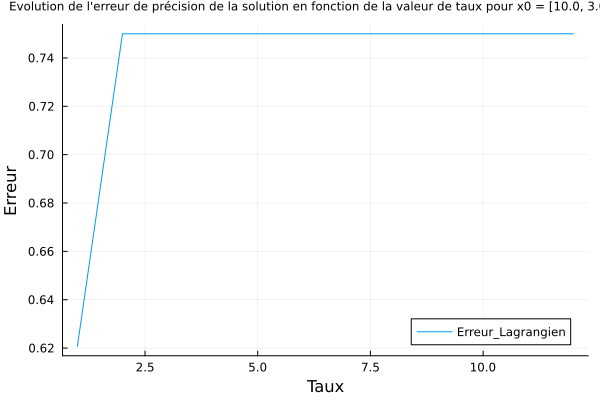

In [7]:
using Plots
include("../src/lagrangien_augmente.jl")

f(x) = 2 * (x[1] + x[2] + x[3] - 3)^2 + (x[1] - x[2])^2 + (x[2] - x[3])^2

gradf(x) = [4 * (x[1] + x[2] + x[3] - 3) + 2 * (x[1] - x[2]),
            4 * (x[1] + x[2] + x[3] - 3) - 2 * (x[1] - x[2]) + 2 * (x[2] - x[3]),
            4 * (x[1] + x[2] + x[3] - 3) - 2 * (x[2] - x[3])]

hessf(x) = [6 2 4; 2 8 2; 4 2 6]

c(x) =  x[1]+x[3]-1
gradc(x) = [1 ;0; 1]
hessc(x) = [0 0 0;0 0 0;0 0 0]


sol = [1.0, 1.0, 1.0]
x0 = [10.0, 3.0, -2.2]

taux = [1.0, 2.0, 3.0, 5.0, 10.0, 11.0, 12.0]
Liste_erreur_Lagrangien = []

for e in taux
    x_lagrangien, _, _, _, _, _=  lagrangien_augmente(f, gradf, hessf, c, gradc, hessc, x0;  τ=e)
    push!(Liste_erreur_Lagrangien, norm(sol - x_lagrangien))
end

plot(taux, Liste_erreur_Lagrangien, label="Erreur_Lagrangien", xlabel="Taux", ylabel="Erreur", title="Evolution de l'erreur de précision de la solution en fonction de la valeur de taux pour x0 = $x0", titlefontsize=8)


Les deux courbes obtenues permettent d'analyser l'impact du paramètre "taux" sur la performance de l'algorithme du Lagrangien Augmenté. La première courbe montre que, à mesure que la valeur du taux augmente, le nombre d'itérations nécessaires diminue. Ainsi, une augmentation du taux permet à l'algorithme de converger plus rapidement.

Cependant, l'analyse de l'évolution de l'erreur de la solution en fonction de taux révèle un inconvénient de l'augmentation de ce paramètre. En effet, lorsque le taux est élevé, l'erreur devient plus importante. Cela suggère qu'une trop grande valeur de taux pourrait nuire à la performance de l'algorithme, car la précision de la solution serait réduite.

En conclusion, il serait optimal de déterminer un taux qui équilibre à la fois un nombre d'itérations raisonnable et une erreur acceptable.